# 02 : Two-Layer Neural Network

Search hyperparameters, save the best net, then reload it from disk and run inference on the test set.

Architecture: `affine -> ReLU -> affine -> softmax`.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%matplotlib inline
import random

import matplotlib.pyplot as plt
import torch

import dl
from dl.paths import REPO_ROOT
from dl.datasets import CLASSES
from dl.utils import accuracy
from dl.models.two_layer_net import TwoLayerNet, find_best_net

# CPU is fine — the full search is ~10 s. Flip to switch back.
USE_CUDA = False
CUDA = USE_CUDA and torch.cuda.is_available()
print('device:', 'cuda' if CUDA else 'cpu')

device: cpu


In [3]:
dl.reset_seed(0)

# The net has explicit biases (b1, b2), so NO bias trick -> D = 3072.
data = dl.datasets.preprocess_cifar10(
    bias_trick=False,
    cuda=CUDA,
    dtype=torch.float32,
    show_examples=False,
)

for k in ['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test']:
    print(f'{k:8s} {str(tuple(data[k].shape)):16s} {data[k].dtype}')

DTYPE, DEVICE = data['X_train'].dtype, data['X_train'].device
CKPT_PATH = REPO_ROOT / 'checkpoints' / 'two_layer_net.pt'
CKPT_PATH.parent.mkdir(exist_ok=True)

/home/saisampathkedari/Deep-Learning/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


X_train  (40000, 3072)    torch.float32
y_train  (40000,)         torch.int64
X_val    (10000, 3072)    torch.float32
y_val    (10000,)         torch.int64
X_test   (10000, 3072)    torch.float32
y_test   (10000,)         torch.int64


## Hyperparameter search

Grid comes from `nn_get_search_params` inside `two_layer_net.py` — edit it there to change the sweep.

In [4]:
best_net, best_stat, best_val = find_best_net(data)

print(f'\nbest validation accuracy: {best_val:.4f}')
best_net.save(str(CKPT_PATH))

hidden=64, lr=0.5, reg=1e-05, decay=0.95, val_acc=0.44%
hidden=64, lr=0.5, reg=0.0001, decay=0.95, val_acc=0.44%
hidden=64, lr=1.0, reg=1e-05, decay=0.95, val_acc=0.42%
hidden=64, lr=1.0, reg=0.0001, decay=0.95, val_acc=0.41%
hidden=128, lr=0.5, reg=1e-05, decay=0.95, val_acc=0.45%
hidden=128, lr=0.5, reg=0.0001, decay=0.95, val_acc=0.45%
hidden=128, lr=1.0, reg=1e-05, decay=0.95, val_acc=0.44%
hidden=128, lr=1.0, reg=0.0001, decay=0.95, val_acc=0.44%

best validation accuracy: 0.4503
Saved in /home/saisampathkedari/Deep-Learning/checkpoints/two_layer_net.pt


## Inference: reload from checkpoint

Construct a fresh net and load the trained weights from disk, to prove the checkpoint round-trips.

In [6]:
# Sizes here are placeholders — .load() replaces self.params wholesale, so the
# hidden size is taken from the checkpoint, not from this constructor call.
net = TwoLayerNet(
    input_size=data['X_train'].shape[1],
    hidden_size=1,
    output_size=10,
    dtype=DTYPE,
    device=str(DEVICE),
)
net.load(str(CKPT_PATH))
# .load() maps to CPU; move the weights to wherever the data lives.
net.params = {k: v.to(device=DEVICE, dtype=DTYPE) for k, v in net.params.items()}

test_acc = accuracy(net.predict(data['X_test']), data['y_test'])
print(f'test accuracy: {test_acc:.4f}')

test accuracy: 0.4686


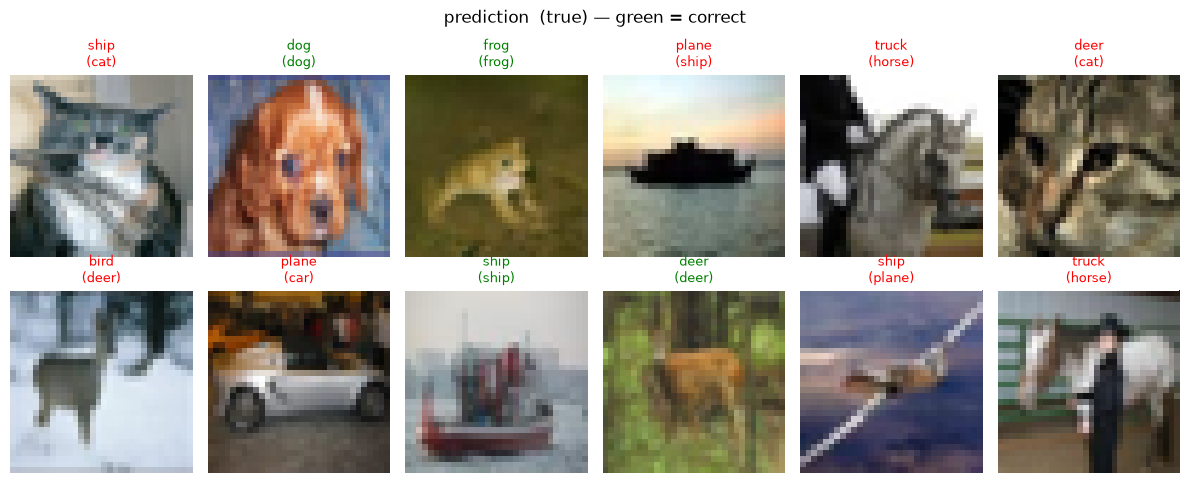

In [ ]:
# Raw (un-normalized) images for display. cifar10() returns the test set in the
# same order as preprocess_cifar10(), so index i lines up with preds[i].
_, _, x_test_raw, _ = dl.datasets.cifar10(x_dtype=torch.float32)
preds = net.predict(data['X_test'])

dl.reset_seed(0)
idxs = random.sample(range(x_test_raw.shape[0]), 12)

plt.figure(figsize=(12, 5))
for i, idx in enumerate(idxs):
    plt.subplot(2, 6, i + 1)
    plt.imshow(dl.tensor_to_image(x_test_raw[idx]))
    plt.axis('off')
    p, t = preds[idx].item(), data['y_test'][idx].item()
    plt.title(f'{CLASSES[p]}\n({CLASSES[t]})',
              color='green' if p == t else 'red', fontsize=9)
plt.suptitle('prediction  (true) — green = correct')
plt.tight_layout()
plt.show()